<a href="https://colab.research.google.com/github/maadhuvijay/Project3-Lego-Classifier/blob/main/Lego_classifier_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## LEGO Brick Classifier

In [1]:
#Install libraries

!pip install gradio
!pip install pyttsx3
!sudo apt install espeak #Install espeak text-to-speech engine
!sudo apt install espeak-ng

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  espeak-data libespeak1 libportaudio2 libsonic0
The following NEW packages will be installed:
  espeak espeak-data libespeak1 libportaudio2 libsonic0
0 upgraded, 5 newly installed, 0 to remove and 30 not upgraded.
Need to get 1,382 kB of archives.
After this operation, 3,178 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd6

In [8]:
#!pip install tensorflow
#!pip install opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 19.6 MB/s eta 0:00:00


In [2]:
# Import libraries

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split

# Import Gradio
import gradio as gr
import pyttsx3
from PIL import Image
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from PIL import Image
import shutil

# Importing Data

In [3]:

# Upload the data_modify ZIP File and Extract the images
from google.colab import files
uploaded = files.upload()

Saving data_modify.zip to data_modify.zip


In [4]:

# Unzip the file

import zipfile
import imghdr

zip_file = "data_modify.zip"  # Change to your filename
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("/content/images")  # Extract to 'images' folder



<ipython-input-4-ee6dba6141af>:4: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [5]:
#Load images


image_folder = "/content/images/data_modify"
images = []
file_names = []


# Load images only if they are valid image files
for filename in os.listdir(image_folder):
    file_path = os.path.join(image_folder, filename)

    # Check if the file is a valid image
    if os.path.isfile(file_path):
        # Check if the file is a valid image
        if imghdr.what(file_path):
            img = Image.open(file_path)
            images.append(img)
            file_names.append({"filename": filename})


# Convert to DataFrame
filename_df = pd.DataFrame(file_names, columns=['filename'])

print(f"Loaded {len(images)} images")




Loaded 1132 images


## Mount in google drive and move to the shared folder

In [6]:
from google.colab import drive
drive.mount('/content/drive')
#shutil.move('/content/images/data_modify', '/content/drive/MyDrive/SharedData/data_modify')

Mounted at /content/drive


## Data visualization

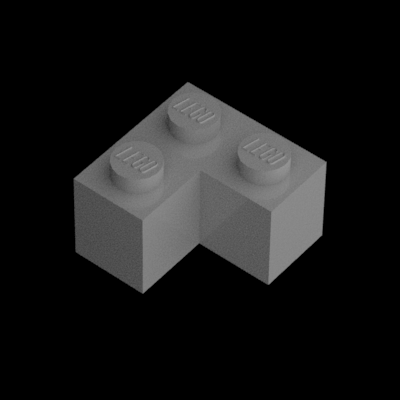

In [7]:
# Print a random image from the list to ensure the import was successful
images[806]

In [8]:
# Check the image is mapped to correct filename
filename_df.iloc[806:815]

,filename
806,2357 brick corner 1x2x2 188L.png
807,3022 Plate 2x2 143L.png
808,3010 brick 1x4 373L.png
809,3001 brick 2x4 183R.png
810,2357 brick corner 1x2x2 039R.png
811,2357 brick corner 1x2x2 024L.png
812,3022 Plate 2x2 315R.png
813,2357 brick corner 1x2x2 002L.png
814,3010 brick 1x4 365R.png


# Pre-processing Data

In [9]:
# Check the size of an image
images[400].size

(400, 400)

In [10]:
# Check the pixel values of images

print(np.array(images[400]).min(), np.array(images[400]).max())

0 147


In [11]:
# Get all the sizes into a list, then convert to a set
sizes = set([img.size for img in images])
sizes

{(400, 400)}

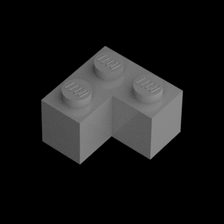

In [12]:
# Use a for loop to resize all images to 224 by 224
target_size = (224,224)

resized_images = [img.resize(target_size, resample = Image.LANCZOS) for img in images]
resized_images[806]

In [13]:
# Verify the resizing of all images
# Get all the sizes into a list, then convert to a set
sizes = set([img.size for img in resized_images])
sizes

{(224, 224)}

### Apply Edge detection, Dilation, Padding to the images

Batched Images Shape: (1132, 224, 224, 3)


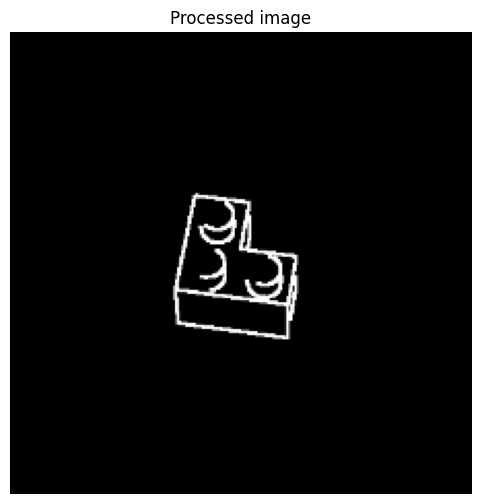

In [14]:

kernel = np.ones((3, 3), np.uint8)

#Convert the images to numpy array
new_images = [np.array(img)  for img in resized_images]

#Add Canny edge detection
edges=[cv2.Canny(img,50,150) for img in new_images]

#Dilate the edges
dilated_edges = [cv2.dilate(img, kernel, iterations=1) for img in edges]

#Add Padding to the images
resized_images_input = [cv2.resize(img, (128, 128)) for img in dilated_edges]
top = bottom = (224 - 128) // 2
left = right = (224 - 128) // 2
resized_images_input = [np.array(img) for img in resized_images_input]
padded_images = [cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=0) for img in resized_images_input]

#Add channel dimension to the images
expanded_edges = [np.stack((img,) * 3, axis=-1) for img in padded_images]
batched_images = np.array(expanded_edges)

#Check the image shape
print("Batched Images Shape:", batched_images.shape)  # Check the shape

# Plot the pre-processed image
plt.figure(figsize=(8,6))
plt.imshow(batched_images[810], cmap="gray")
plt.title("Processed image")
plt.axis("off")
plt.show()


In [15]:
# Convert to NumPy array and then to float32
float_images = [np.array(img).astype(np.float32) for img in batched_images]

#Check the pixel values to make sure they are between 0 and 255
print("Pixel Values:")
print(np.array(float_images[700]).min(), np.array(float_images[700]).max())


Pixel Values:
0.0 255.0


In [16]:
# Normalize pixel values to range [0, 1]
normalized_images = [img/255.0 for img in float_images]

print("Pixel Values:")
print(np.array(normalized_images[700]).min(), np.array(normalized_images[700]).max())


Pixel Values:
0.0 1.0


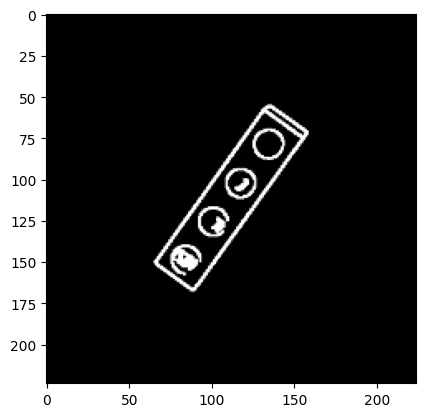

In [17]:
# Display the normalized image

plt.imshow(normalized_images[906])
plt.show()

In [18]:
#check the channel dimension
normalized_images[400].shape

(224, 224, 3)

In [19]:
# Convert the images to grayscale

grayscale_images = tf.image.rgb_to_grayscale(normalized_images)
print(grayscale_images.shape)

(1132, 224, 224, 1)


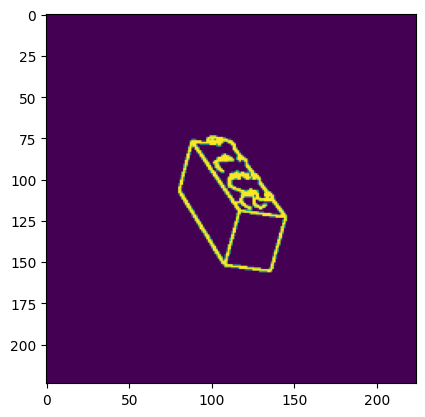

In [28]:
# Plot the grayscale image
plt.imshow(grayscale_images[506])
plt.show()

In [30]:
#Check the pixels of gray scale images
print("Pixel Values:")
print(np.array(grayscale_images[506]).min(), np.array(grayscale_images[506]).max())


Pixel Values:
0.0 0.9999


# Labels

In [31]:
# check the filename dataframe before splitting the file name
filename_df.head()

,filename
0,2357 brick corner 1x2x2 117R.png
1,2357 brick corner 1x2x2 278L.png
2,3010 brick 1x4 376L.png
3,3022 Plate 2x2 037R.png
4,3022 Plate 2x2 300L.png


In [32]:
# Function to handle different filename structures
def split_filename(filename):
    parts = filename.replace('.png', '').split()  # Remove .png if needed and split by space
    design_id = parts[0]  # First part is the design ID
    image_id = parts[-1]  # Last part is the image ID
    element_size = parts[-2]  # Second last part is the element size
    element_name = " ".join(parts[1:-2])  # Everything in between is the element name
    return pd.Series([design_id, element_name, element_size, image_id])


# Apply function to DataFrame
filename_df[['design_id', 'element_name', 'element_size', 'image_#']] = filename_df['filename'].apply(split_filename)


filename_df.head()

,filename,design_id,element_name,element_size,image_#
0,2357 brick corner 1x2x2 117R.png,2357,brick corner,1x2x2,117R
1,2357 brick corner 1x2x2 278L.png,2357,brick corner,1x2x2,278L
2,3010 brick 1x4 376L.png,3010,brick,1x4,376L
3,3022 Plate 2x2 037R.png,3022,Plate,2x2,037R
4,3022 Plate 2x2 300L.png,3022,Plate,2x2,300L


In [33]:
# Check for null values
filename_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1132 entries, 0 to 1131
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   filename      1132 non-null   object
 1   design_id     1132 non-null   object
 2   element_name  1132 non-null   object
 3   element_size  1132 non-null   object
 4   image_#       1132 non-null   object
dtypes: object(5)
memory usage: 44.3+ KB


In [34]:
# Split the images and design id into X and y

X = grayscale_images
y = filename_df['design_id']

y[:5]

,design_id
0,2357
1,2357
2,3010
3,3022
4,3022


In [35]:
#Check the total counts of each lego piece

filename_df['design_id'].value_counts()

,count
design_id,
2357,283
3010,283
3022,283
3001,283


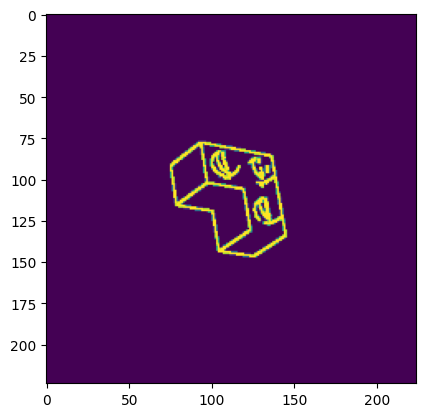

In [36]:
# Plot the image and check if X and y labels match.

plt.imshow(X[500])
plt.show()

In [37]:
# And the corresponding label to check they are matching

y[500]

'2357'

In [38]:
# Check the total number of classes
y.nunique()

4

In [39]:
# Get the actual class values
lego_classes = pd.Series(y).unique()

print(f"Lego Design Ids: {lego_classes}")

Lego Design Ids: ['2357' '3010' '3022' '3001']


In [40]:
#Check y shape to see the array dimension
y.shape

(1132,)

In [41]:
# Convert values to numpy arrays
X = np.array(X)
y = np.array(y)

In [42]:
#Check the shape of the X and yvariables
X.shape, y.shape

((1132, 224, 224, 1), (1132,))

In [43]:
# Now we'll split our data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y)

## Checking if the length of training and testing data sets are same

In [44]:
# Print the length of each list
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

849
849
283
283


## Check if the training image & labels match before augmentation

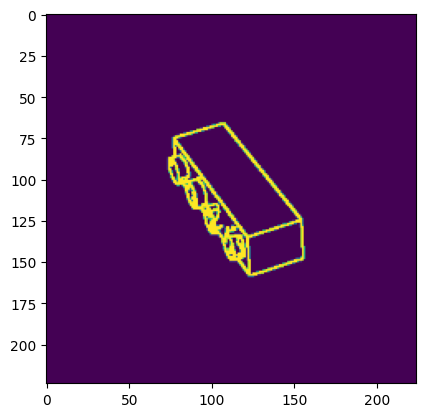

In [45]:
plt.imshow(X_train[100])

plt.show()

In [46]:
y_train[100]

'3010'

## Check if the testing image & labels match before augmentation

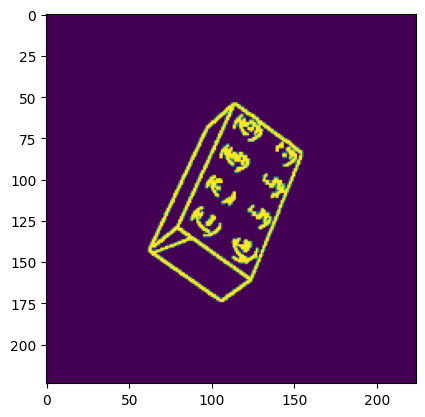

In [47]:
plt.imshow(X_test[281])

plt.show()

In [48]:
y_test[281]

'3001'

## Augmentation

In [49]:

# Apply augmentation to the whole training dataset

# Define the augmentation pipeline
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip('horizontal'), # Random horizontal flip
    tf.keras.layers.RandomZoom(0.2),  # Random zoom (20%)
    tf.keras.layers.RandomFlip('vertical'),

])

# Create variables to hold the X and y training data
X_train_aug = []
y_train_aug = []

# Loop through all the images.
for i in range(len(X_train)):
      img = X_train[i]
      label = y_train[i]



    # Ensure that the input data has the correct shape
      img = np.expand_dims(img, axis=0)  # Add batch dimension

    # Add 12 images for every original image
      for j in range(12):
          X_train_aug.append(data_augmentation(img, training=True)[0].numpy())
          y_train_aug.append(label)


# Print the length of each list
print(len(X_train_aug))
print(len(y_train_aug))



10188
10188


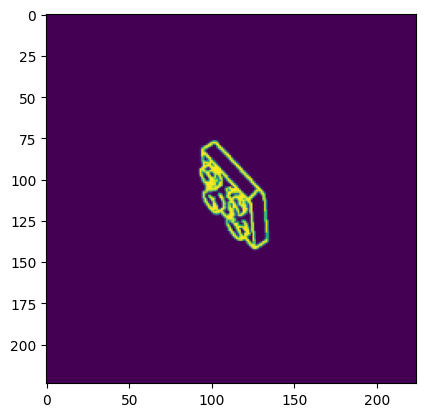

In [50]:
#Check the image and labels after augmentation
plt.imshow(X_train_aug[5])

plt.show()

In [51]:
y_train_aug[5]



'3022'

In [52]:


# Reshape test data for the model
X_test_np = []
for img in X_test:
  # Add a channel dimension for grayscale images

    X_test_np.append(img)

# Convert to numpy array
X_test_np = np.array(X_test_np)

# Check the shape of the first image
X_test_np[5].shape



(224, 224, 1)

# One hot Encoding of the target column

In [53]:
#One hot encode the y data

y_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(np.array(y_train_aug).reshape(-1, 1))
y_train_aug_enc = y_encoder.transform(np.array(y_train_aug).reshape(-1, 1))
y_test_enc = y_encoder.transform(np.array(y_test).reshape(-1, 1))


In [54]:
# Convert values to numpy arrays


X_train_aug_np = np.array(X_train_aug)
X_test_np = np.array(X_test_np)
y_train_aug_np = np.array(y_train_aug_enc)
y_test_np = np.array(y_test_enc)



## Check the shapes of augmented X and Y for batch dimensions

In [55]:
X_train_aug_np.shape

(10188, 224, 224, 1)

In [56]:
X_test_np.shape

(283, 224, 224, 1)

In [57]:
y_test_np.shape

(283, 4)

In [58]:
y_train_aug_np.shape

(10188, 4)

In [59]:
# Split the training dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_aug_np, y_train_aug_np, test_size=0.3, random_state=42)

## Creating a CNN model

### Model1 -Basic CNN model

In [60]:
# Define a CNN model

from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.metrics import AUC
from tensorflow.keras import initializers


model1 = keras.Sequential([

    #Layer 1
    layers.Conv2D(32, (3, 3), activation='relu',input_shape=(224, 224, 1)),
    layers.MaxPooling2D((2, 2)),
    #Layer 2
    layers.Conv2D(128, (3, 3), activation='relu',kernel_regularizer=keras.regularizers.l2(0.0001)),
    layers.MaxPooling2D((2, 2)),
    #Layer 3
    layers.Conv2D(128, (3, 3), activation='relu',kernel_regularizer=keras.regularizers.l2(0.0001)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    #Layer 4
    layers.Dense(256, activation='relu',kernel_regularizer=keras.regularizers.l2(0.0001)),
    layers.Dropout(0.3),
    #Layer 5
    layers.Dense(4, activation='softmax')
])

#lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Compile the model
model1.compile(optimizer=Adam(learning_rate=0.00003), loss='categorical_crossentropy', metrics=['accuracy'])


# Create an EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Metric to monitor (e.g., 'val_loss' or 'val_accuracy')
    patience=5,          # Number of epochs to wait for improvement before stopping
    restore_best_weights=True  # Restore the weights of the best epoch
)

# Train the model with the callback
history = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]  # Pass the EarlyStopping callback
)
# Evaluate the model using the testing data
model1.evaluate(X_test_np, y_test_np)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.6149 - loss: 0.9812 - val_accuracy: 0.8178 - val_loss: 0.5138
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8338 - loss: 0.4790 - val_accuracy: 0.8842 - val_loss: 0.3542
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8885 - loss: 0.3476 - val_accuracy: 0.9087 - val_loss: 0.2828
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9169 - loss: 0.2675 - val_accuracy: 0.9346 - val_loss: 0.2321
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9336 - loss: 0.2321 - val_accuracy: 0.9450 - val_loss: 0.1939
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9538 - loss: 0.1840 - val_accuracy: 0.9545 - val_loss: 0.1746
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9678 - loss: 0.1503 - val_accuracy: 0.9640 - val_loss: 0.1520
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9736 - loss: 0.1362 - val_acc

[0.08423561602830887, 0.9858657121658325]

## Model training

The model was trained with

1. **Activation functions** "relu" on the convolution layers and "softmax" for the output layer as this is a multi-class image classification problem.
2. The model used **"categorical cross entropy"** for the loss function and measured "Accuracy" as the validation metric.
3. **Early stopping** is used as a training technique to prevent overfitting in the model.

4. The **learning rate** in the optimizer "Adam" was adjusted to different values (0.01,0.001,0.0001, 0.00001,0.00003,0.00005). I noticed a lower learning rate achieved better results opposed to higher learning rates. when the rates were higher the validation accuracy and loss remained stagnant for most of the time and the model was not learning.  
5. A **LR scheduler** to vary the learning rate based on model response was also implemented. But manually choosing the rates gave better understanding.

## Model1 Evaluation

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9809 - loss: 0.1063 

Test Accuracy: 98.59%
Test Loss: 0.0842


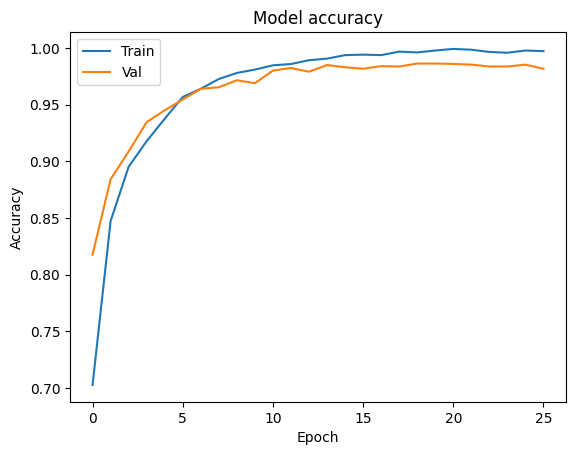

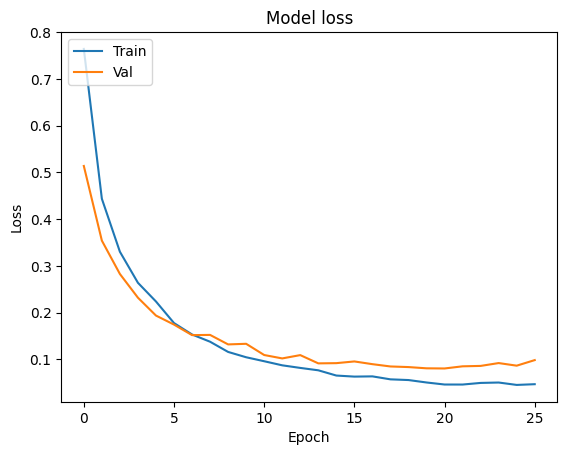

In [61]:
# Evaluate the model using the testing data
test_results= model1.evaluate(X_test_np, y_test_np)
print(f"\nTest Accuracy: {test_results[1]*100:.2f}%")
print(f"Test Loss: {test_results[0]:.4f}")


# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

## Model1 Predictions - These are predictions using the X_test and Y_test data

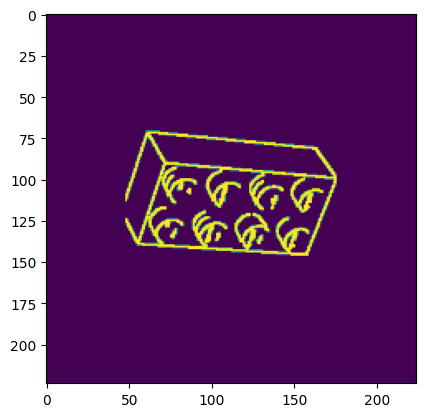

y label: 3001

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Class 0: 0.000%
Class 1: 100.000%
Class 2: 0.000%
Class 3: 0.000%
Prediction Probabilities: [[7.1499860e-21 1.0000000e+00 1.3460015e-11 3.5195132e-17]]

Predicted Lego ID: 3001


In [64]:
# Make predictions using X_test and y_test data

img_id = 200
lego_bricks = { 0:"2357",
               1:"3001",
               2:"3010",
               3:"3022"}

input_image = X_test[img_id]

plt.imshow(X_test[img_id])
plt.show()

print(f"y label: {y_test[img_id]}\n")

# Add a batch dimension:
input_image = input_image[np.newaxis, ...]

#Make prediction
prediction = model1.predict(input_image)
lego_class = np.argmax(prediction)   # Lego with high probability
node_values = prediction[0]  # First image in the batch

# Print probabilities
for i, value in enumerate(node_values):
  percentage = value * 100
  print(f"Class {i}: {percentage:.3f}%")

#Print the predicted lego class
print(f"Prediction Probabilities: {prediction}")
print(f"\nPredicted Lego ID: {lego_bricks[lego_class]}")





In [65]:
model1.save('/content/drive/MyDrive/model1_trained.keras')  # Save model


In [66]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 128)       │          36,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,012,046 (255.63 MB)

 Trainable params: 22,337,348 (85.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44,674,698 (170.42 MB)

# Model 2 - L1 Regularization

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.metrics import AUC
from tensorflow.keras import initializers

model2 = keras.Sequential([

    #Layer 1
    layers.Conv2D(64, (3, 3), activation='relu',input_shape=(224, 224, 1)),
    layers.MaxPooling2D((2, 2)),

    #Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    #Layer 3
    layers.Conv2D(128, (3, 3), activation='relu',kernel_regularizer=keras.regularizers.l1(0.01)),
    layers.MaxPooling2D((2, 2)),

    #Layer 4
    layers.Conv2D(128, (3, 3), activation='relu',kernel_regularizer=keras.regularizers.l1(0.01)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),

    #Layer 5
    layers.Dense(512, activation='relu',kernel_regularizer=keras.regularizers.l1(0.01)),

    #Layer 6
    layers.Dense(4, activation='softmax')
])

# Compile the model
model2.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])


# Create an EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# Train the model with the callback
history = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping]  # Pass the EarlyStopping callback
)
# Evaluate the model using the testing data
model2.evaluate(X_test_np, y_test_np)


Epoch 1/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.2959 - loss: 668.6819 - val_accuracy: 0.3144 - val_loss: 156.6200
Epoch 2/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3687 - loss: 89.8739 - val_accuracy: 0.2486 - val_loss: 22.2783
Epoch 3/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2673 - loss: 18.9714 - val_accuracy: 0.2486 - val_loss: 10.4891
Epoch 4/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2540 - loss: 8.4740 - val_accuracy: 0.2486 - val_loss: 3.8397
Epoch 5/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2647 - loss: 3.1019 - val_accuracy: 0.2486 - val_loss: 2.0116
Epoch 6/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2557 - loss: 1.9662 - val_accuracy: 0.2486 - val_loss: 1.9469
Epoch 7/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2598 - loss: 1.9458 - val_accuracy: 0.2486 - val_loss: 1.9463
Epoch 8/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2644 - loss: 1.9455 -

[1.9487104415893555, 0.2226148396730423]

# Model2 [L1 regularization Model] - Evaluation

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2255 - loss: 1.9477 

Test Accuracy: 22.26%
Test Loss: 1.9487


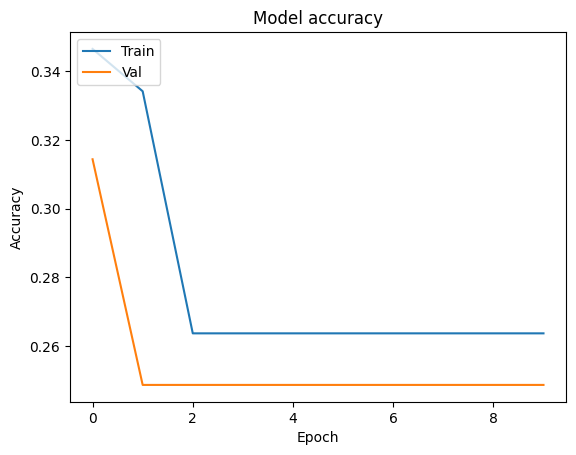

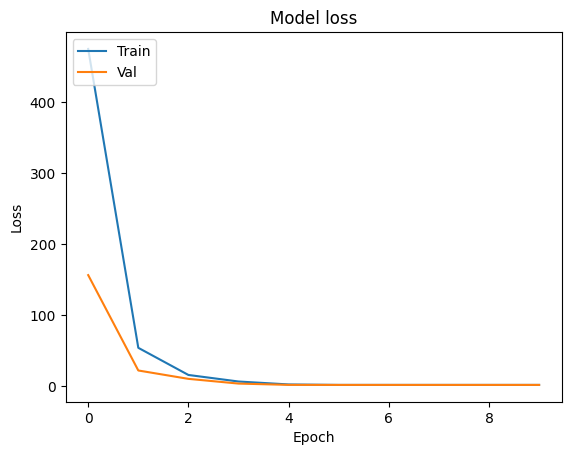

In [ ]:
# Evaluate the model using the testing data
test_results= model2.evaluate(X_test_np, y_test_np)
print(f"\nTest Accuracy: {test_results[1]*100:.2f}%")
print(f"Test Loss: {test_results[0]:.4f}")


# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

## L1 regularization observations

The L1 diagnostic curves showed erratic differences between the model trainging and validation accuracy as well as with training and validation loss.

In [ ]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       9,437,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,096,270 (110.99 MB)

 Trainable params: 9,698,756 (37.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,397,514 (74.00 MB)

# Model3 - With dropouts

In [ ]:
# Define the model to explore the dropout regularization method

model3 = keras.Sequential([

    #Layer 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)),
    layers.MaxPooling2D((2, 2)),

    #Layer 2
    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.MaxPooling2D((2, 2)),

    #Layer 3
    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    #Layer 4
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    #Layer 5
    layers.Dense(4, activation='softmax')
])

# Compile the model

model3.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])

# Create an EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
# Train the model with the callback
history = model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping]
)

# Evaluate the model using the testing data
model3.evaluate(X_test_np, y_test_np)


Epoch 1/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5960 - loss: 0.8763 - val_accuracy: 0.8116 - val_loss: 0.4545
Epoch 2/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8407 - loss: 0.4080 - val_accuracy: 0.8911 - val_loss: 0.2802
Epoch 3/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9081 - loss: 0.2534 - val_accuracy: 0.9195 - val_loss: 0.2216
Epoch 4/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9356 - loss: 0.1824 - val_accuracy: 0.9392 - val_loss: 0.1529
Epoch 5/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9551 - loss: 0.1231 - val_accuracy: 0.9627 - val_loss: 0.1148
Epoch 6/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9681 - loss: 0.0934 - val_accuracy: 0.9706 - val_loss: 0.0944
Epoch 7/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9754 - loss: 0.0708 - val_accuracy: 0.9699 - val_loss: 0.0880
Epoch 8/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9840 - loss: 0.0596 - val_accu

[0.0985364317893982, 0.9646643400192261]

## Model 3 Evaluations

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9704 - loss: 0.0927 

Test Accuracy: 96.47%
Test Loss: 0.0985


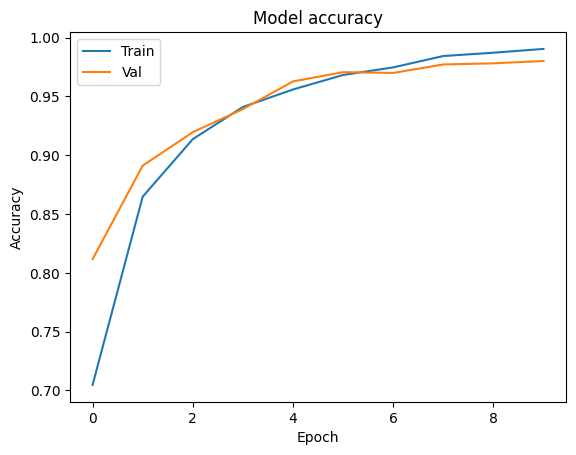

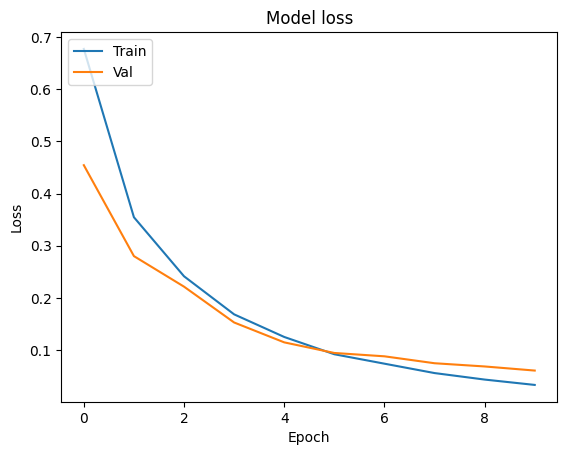

In [ ]:
# Evaluate the model using the testing data
test_results= model3.evaluate(X_test_np, y_test_np)
print(f"\nTest Accuracy: {test_results[1]*100:.2f}%")
print(f"Test Loss: {test_results[0]:.4f}")

# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [ ]:
model3.summary()

# Model 4 - L2 Regularization

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.metrics import AUC
from tensorflow.keras import initializers

model4 = keras.Sequential([

    #Layer 1
    layers.Conv2D(32, (3, 3), activation='relu',input_shape=(224, 224, 1)),
    layers.MaxPooling2D((2, 2)),


    #Layer 2
    layers.Conv2D(128, (3, 3), activation='relu',kernel_regularizer=keras.regularizers.l2(0.03)),
    layers.MaxPooling2D((2, 2)),

    #Layer 3
    layers.Conv2D(128, (3, 3), activation='relu',kernel_regularizer=keras.regularizers.l2(0.03)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),

    #Layer 4
    layers.Dense(256, activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)),

    #Layer 5
    layers.Dense(4, activation='softmax')
])

# Compile the model

model4.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])


# Create an EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Metric to monitor (e.g., 'val_loss' or 'val_accuracy')
    patience=5,          # Number of epochs to wait for improvement before stopping
    restore_best_weights=True  # Restore the weights of the best epoch
)

# Train the model with the callback
history = model4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=32,
    callbacks=[early_stopping]  # Pass the EarlyStopping callback
)
# Evaluate the model using the testing data
model4.evaluate(X_test_np, y_test_np)


Epoch 1/12
223/223 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.6506 - loss: 5.8792 - val_accuracy: 0.8361 - val_loss: 3.7105
Epoch 2/12
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8531 - loss: 3.2967 - val_accuracy: 0.8606 - val_loss: 2.4101
Epoch 3/12
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8950 - loss: 2.1121 - val_accuracy: 0.8963 - val_loss: 1.6060
Epoch 4/12
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9254 - loss: 1.4120 - val_accuracy: 0.8904 - val_loss: 1.1566
Epoch 5/12
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9464 - loss: 0.9927 - val_accuracy: 0.9149 - val_loss: 0.8435
Epoch 6/12
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9558 - loss: 0.7365 - val_accuracy: 0.9212 - val_loss: 0.6805
Epoch 7/12
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9666 - loss: 0.5672 - val_accuracy: 0.9493 - val_loss: 0.5263
Epoch 8/12
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9737 - loss: 0.4577 - val_acc

[0.2708067297935486, 0.9681978821754456]

## Model 4 - Evaluations

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9746 - loss: 0.2621 

Test Accuracy: 96.82%
Test Loss: 0.2708


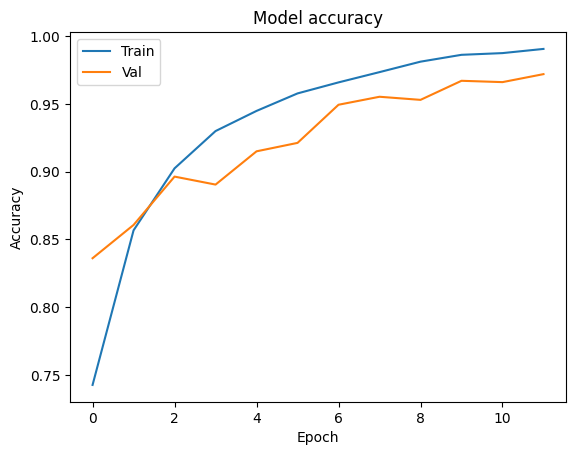

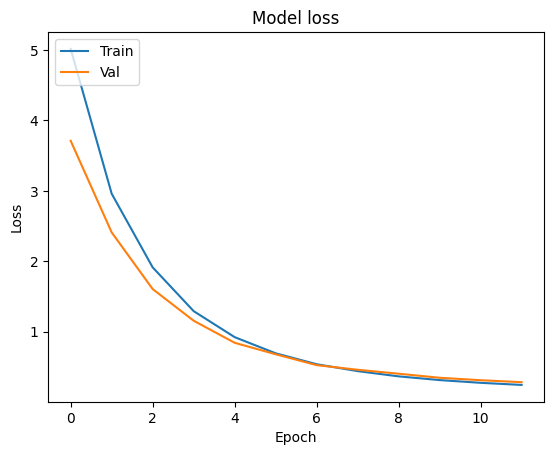

In [ ]:
# Evaluate the model using the testing data
test_results= model4.evaluate(X_test_np, y_test_np)
print(f"\nTest Accuracy: {test_results[1]*100:.2f}%")
print(f"Test Loss: {test_results[0]:.4f}")


# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [ ]:
model4.save('/content/drive/MyDrive/model4_trained.keras')

## Hyperparameter tuning - Random search - This part of code was already run during model optimization. Results are below. no need to run again

In [ ]:

!pip install keras-tuner -q

import keras
from keras import layers
from keras_tuner import HyperModel, RandomSearch
import tensorflow as tf

# Define a model using HyperModel (used for hyperparameter tuning)
class CNNHyperModel(HyperModel):
    def build(self, hp):
        # Create a Sequential model
        model3 = keras.Sequential()

        # Hyperparameters for Conv2D layers
        model3.add(layers.Conv2D(
            filters=hp.Int('conv_1_filters', min_value=32, max_value=128, step=32),
            kernel_size=(3, 3),
            activation='relu',
            input_shape=(224, 224, 3)
        ))
        model3.add(layers.MaxPooling2D((2, 2)))

        model3.add(layers.Conv2D(
            filters=hp.Int('conv_2_filters', min_value=32, max_value=128, step=32),
            kernel_size=(3, 3),
            activation='relu'
        ))
        model3.add(layers.MaxPooling2D((2, 2)))

        model3.add(layers.Conv2D(
            filters=hp.Int('conv_3_filters', min_value=32, max_value=128, step=32),
            kernel_size=(3, 3),
            activation='relu'
        ))
        model3.add(layers.Flatten())

        # Hyperparameter for Dense layer
        model3.add(layers.Dense(
            units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
            activation='relu'
        ))

        # Output layer
        model3.add(layers.Dense(4, activation='softmax'))  # Binary classification

        # Compile the model
        model3.compile(
            optimizer=keras.optimizers.Adam(),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        return model3


# Instantiate the HyperModel
cnn_hypermodel = CNNHyperModel()

# Define the hyperparameter search
tuner = RandomSearch(
    cnn_hypermodel,
    objective='val_accuracy',  # We aim to optimize validation accuracy
    max_trials=5,               # Number of different hyperparameter combinations to test
    executions_per_trial=3,     # How many times to train each model
    directory='tuner_dir',      # Directory to save the results
    project_name='cnn_batch_tuning'  # Project name
)

# Perform the hyperparameter search
tuner.search(X_train, y_train, validation_data=(X_val, y_val), epochs=25, batch_size=32)

# Get the best hyperparameters
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model on the test data
best_model.evaluate(X_test_np, y_test_np)





Trial 5 Complete [00h 10m 02s]
val_accuracy: 0.32159624497095746

Best val_accuracy So Far: 0.3262910743554433
Total elapsed time: 00h 52m 41s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 292ms/step - accuracy: 0.2171 - loss: 6.6949


[6.253284454345703, 0.23591549694538116]

## These are the hyperparameter tuning results: No need to run again

In [ ]:

# Print best hyperparameters
print("Best Hyperparameters Found:")
for param in best_hyperparameters.values:  # Use best_hyperparameters instead of best_hps
    print(f"{param}: {best_hyperparameters.get(param)}")

Best Hyperparameters Found:
conv_1_filters: 32
conv_2_filters: 128
conv_3_filters: 128
dense_units: 128


#Gradio application code

## Python offline text to speech code [Pyttsx library]

In [67]:
#Initialize the TTS engine
engine=pyttsx3.init()

def spell_out_number(number_str):
    return ' '.join(number_str)


#Funciton to convert text to speech
def text_to_speech(text):

    engine.setProperty('rate', 200)

    # Spell digits in the text
    words = text.split()
    spoken_words = []
    for word in words:
        if word.isdigit():
            spoken_words.append(spell_out_number(word))
        else:
            spoken_words.append(word)
    spoken_text = ' '.join(spoken_words)

    engine.save_to_file(spoken_text, "output.wav")
    engine.runAndWait()
    return "output.wav"

## OpenAI text to speech module

In [79]:

import openai
import os

# Set your API key

openai_api_key="Enter your API key here"

openai.api_key = openai_api_key

def spell_out_number(number_str):
    return ' '.join(number_str)


#Funciton to convert text to speech
def text_to_speech_openai(text):


    # Spell digits in the text
    words = text.split()
    spoken_words = []
    for word in words:
        if word.isdigit():
            spoken_words.append(spell_out_number(word))
        else:
            spoken_words.append(word)
    spoken_text = ' '.join(spoken_words)

    response = openai.audio.speech.create(
        model="tts-1",
        voice="shimmer",
        input=text
    )
    output_path = "output_openai.wav"
    response.stream_to_file(output_path)
    return output_path



## Gradio - Input image processing

In [72]:
# process image function called from Gradio application

def process_image(img):

  lego_bricks = {
               0:"2357",
               1:"3001",
               2:"3010",
               3:"3022"}

  kernel = np.ones((3, 3), np.uint8)

  # Image pre-processing


  array_input = np.array(img)
  edges_input=cv2.Canny(array_input,50,150)

  dilated_edges_input = cv2.dilate(edges_input, kernel, iterations=1)
  resized_image_input = cv2.resize(dilated_edges_input, (100, 100))

  # Add padding to make it 224x224

  top = bottom = (224 - 100) // 2
  left = right = (224 - 100) // 2
  padded_image = cv2.copyMakeBorder(resized_image_input, top, bottom, left, right, cv2.BORDER_CONSTANT, value=0)
  expanded_edges_input = np.stack((padded_image,) * 3, axis=-1)
  float_image_input = np.array(expanded_edges_input).astype(np.float32)
  normalized_image_input = float_image_input/255
  grayscale_image = tf.image.rgb_to_grayscale(normalized_image_input)
  expanded_image_input = np.expand_dims(grayscale_image, axis=0)

  #Model prediction
  predict_input_image= model1.predict(expanded_image_input)
  predicted_class = np.argmax(predict_input_image)  # Get class index


  probability_lines=[]
  probs = predict_input_image[0]

  probability_lines = [

        f"Class {i} : Lego brick ID {lego_bricks[i]} :Probability {prob * 100:.2f}%"
        for i, prob in enumerate(probs)
    ]


  probabilities_text = "\n".join(probability_lines)

  # Spelled-out voice output
  brick_id = lego_bricks[predicted_class]
  info_text = f"The Lego is: {brick_id}"
  audio_path = text_to_speech_openai(info_text)

  return probabilities_text, audio_path

## Gradio app Interface and Launch

In [78]:
app = gr.Interface(


    fn=process_image,
    inputs=gr.Image(type="pil"),
    outputs=[
              gr.Textbox(label="Lego probability"),
              gr.Audio(label="Generated speech",type="filepath"),
              ],
    submit_btn="Predict Lego Brick",
    title="LEGO Type Classifier",
    description="Upload an image of a LEGO brick to classify its type.",

)

app.launch(debug=True)

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://2dd3fd829e9c38652a.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


<ipython-input-71-789009f1e26c>:34: DeprecationWarning: Due to a bug, this method doesn't actually stream the response content, `.with_streaming_response.method()` should be used instead
  response.stream_to_file(output_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


<ipython-input-71-789009f1e26c>:34: DeprecationWarning: Due to a bug, this method doesn't actually stream the response content, `.with_streaming_response.method()` should be used instead
  response.stream_to_file(output_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


<ipython-input-71-789009f1e26c>:34: DeprecationWarning: Due to a bug, this method doesn't actually stream the response content, `.with_streaming_response.method()` should be used instead
  response.stream_to_file(output_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


<ipython-input-71-789009f1e26c>:34: DeprecationWarning: Due to a bug, this method doesn't actually stream the response content, `.with_streaming_response.method()` should be used instead
  response.stream_to_file(output_path)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://2dd3fd829e9c38652a.gradio.live
